This codelab is largely based on [scikit-learn example code](https://scikit-learn.org/stable/auto_examples/ensemble/plot_isolation_forest.html#sphx-glr-auto-examples-ensemble-plot-isolation-forest-py).


In [ ]:
%matplotlib inline


# IsolationForest example


An example using :class:`sklearn.ensemble.IsolationForest` for anomaly
detection.

The IsolationForest 'isolates' observations by randomly selecting a feature
and then randomly selecting a split value between the maximum and minimum
values of the selected feature.

Since recursive partitioning can be represented by a tree structure, the
number of splittings required to isolate a sample is equivalent to the path
length from the root node to the terminating node.

This path length, averaged over a forest of such random trees, is a measure
of normality and our decision function.

Random partitioning produces noticeable shorter paths for anomalies.
Hence, when a forest of random trees collectively produce shorter path lengths
for particular samples, they are highly likely to be anomalies.




Automatically created module for IPython interactive environment
{1, -1}
[37, 89, 104, 110, 131, 142, 237, 239, 256, 262, 289, 304, 310, 326, 331, 342, 389, 391, 396, 398]


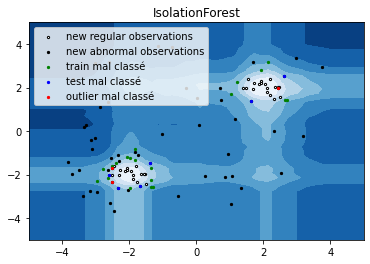

In [1]:
print(__doc__)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

rng = np.random.RandomState(42)

# Generate train data
X = 0.3 * rng.randn(200, 2)
X_train = np.r_[X + 2, X - 2]
X_outliers_train = rng.uniform(low=-4, high=4, size=(5, 2))
# Generate some regular novel observations
X = 0.3 * rng.randn(20, 2)
X_test = np.r_[X + 2, X - 2]
# Generate some abnormal novel observations
X_outliers = rng.uniform(low=-4, high=4, size=(50, 2))

# fit the model
clf = IsolationForest(
    n_estimators=100, max_samples="auto", random_state=rng, contamination=0.06
)
clf.fit(np.concatenate((X_train, X_outliers_train), axis=0))
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
y_pred_outliers = clf.predict(X_outliers)

# plot the line, the samples, and the nearest vectors to the plane
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.title("IsolationForest")
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

# b1 = plt.scatter(X_train[:, 0], X_train[:, 1], c='white',
#                s=5, edgecolor='k')
b2 = plt.scatter(X_test[:, 0], X_test[:, 1], c="white", s=5, edgecolor="k")
c = plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="black", s=5, edgecolor="k")

# Affichage des points mal classés

print(set(y_pred_train))

index_wrong_classe = [i for i, x in enumerate((y_pred_train != 1)) if x]
print(index_wrong_classe)
w1 = plt.scatter(
    X_train[index_wrong_classe, 0],
    X_train[index_wrong_classe, 1],
    color="g",
    s=5,
    label="train mal classé",
)

index_wrong_classe = [i for i, x in enumerate((y_pred_test != 1)) if x]
w2 = plt.scatter(
    X_test[index_wrong_classe, 0],
    X_test[index_wrong_classe, 1],
    color="b",
    s=5,
    label="test mal classé",
)

index_wrong_classe = [i for i, x in enumerate((y_pred_outliers != -1)) if x]
w3 = plt.scatter(
    X_outliers[index_wrong_classe, 0],
    X_outliers[index_wrong_classe, 1],
    color="r",
    s=5,
    label="outlier mal classé",
)


plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.legend(
    [b2, c, w1, w2, w3],
    [
        "new regular observations",
        "new abnormal observations",
        "train mal classé",
        "test mal classé",
        "outlier mal classé",
    ],
    loc="upper left",
)
plt.show()

In [ ]:
print(
    "Proportion d'exemples de test mal classés par le modèle :",
    np.sum([y_pred_test == -1]) / len(y_pred_test),
)
print(
    "Proportion d'outlier détectés par le modèle :",
    np.sum([y_pred_outliers == -1]) / len(y_pred_outliers),
)

Proportion d'exemples de test mal classés par le modèle : 0.2325
Proportion d'outlier détectés par le modèle : 0.94
